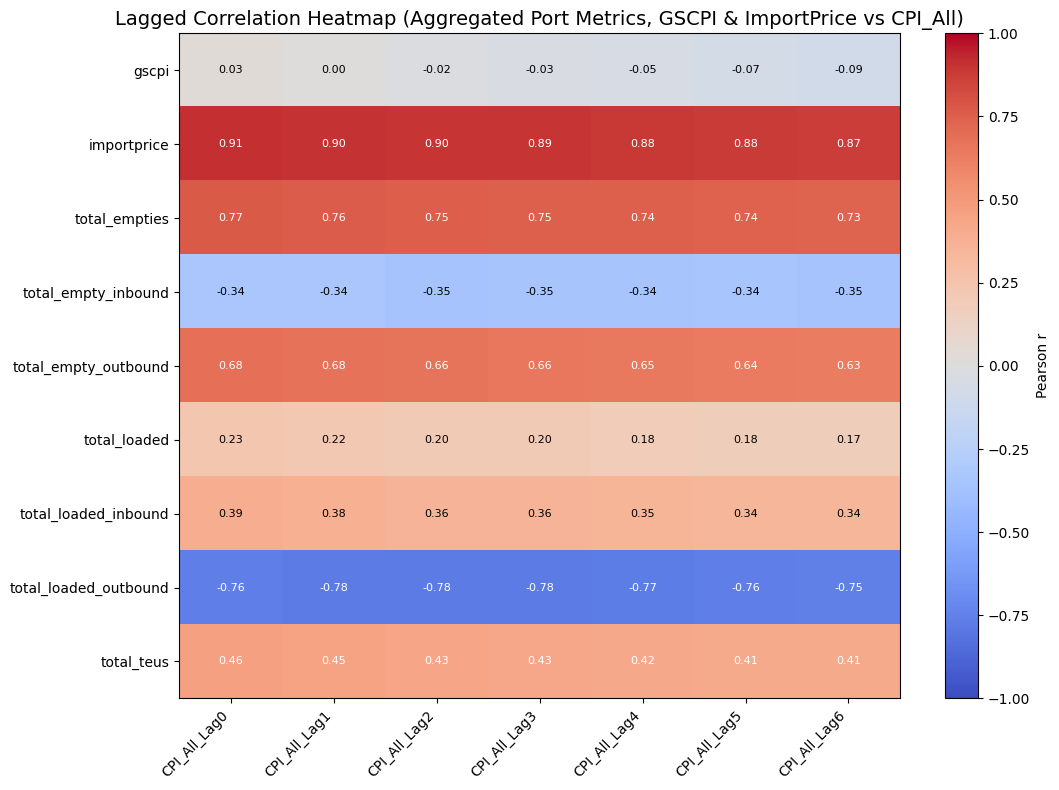

In [ ]:
# ==========================================
# Lagged Correlation Heatmap (safe version)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your full dataset
df = pd.read_csv("inflationship_output/ports_with_cpi_full_totals.csv")

# Ensure proper date parsing and numeric conversion
df["date"] = pd.to_datetime(df["date"], format="%Y-%m", errors="coerce")
for col in df.columns:
    if col != "date":
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Define CPI and target variables
cpi_col = "cpi_all"
y_cols = [
    "total_loaded_inbound", "total_loaded_outbound",
    "total_empty_inbound", "total_empty_outbound",
    "total_loaded", "total_empties", "total_teus",
    "gscpi", "importprice"
]
y_cols = [c for c in y_cols if c in df.columns]  # include only existing columns

if not y_cols:
    raise ValueError("No valid target columns found in dataset!")

# Compute lagged correlations safely (0–6 months)
max_lag = 6
records = []

for y in y_cols:
    if y not in df.columns:
        continue
    for lag in range(max_lag + 1):
        # Only compute if CPI column exists
        if cpi_col in df.columns:
            corr = df[y].corr(df[cpi_col].shift(lag))
            records.append({"variable": y, "lag": lag, "corr": corr})

# Convert records to DataFrame
if not records:
    raise ValueError("No correlation records were computed — check column names.")
lag_df = pd.DataFrame(records)

# Check if 'lag' column exists
if "lag" not in lag_df.columns:
    raise KeyError("'lag' column missing — correlation computation failed.")

# Create label column for plotting
lag_df["lag_label"] = "CPI_All_Lag" + lag_df["lag"].astype(str)

# Pivot for heatmap
heatmap_data = lag_df.pivot(index="variable", columns="lag_label", values="corr")

# --- Plot heatmap ---
fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(heatmap_data, aspect="auto", interpolation="nearest", cmap="coolwarm", vmin=-1, vmax=1)

# Annotate cells with correlation values
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.iloc[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color="white" if abs(val) > 0.4 else "black")

# Axis setup
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

# Add colorbar and title
fig.colorbar(im, label="Pearson r")
plt.title("Lagged Correlation Heatmap (Aggregated Port Metrics, GSCPI & ImportPrice vs CPI_All)", fontsize=14)
plt.tight_layout()
plt.show()


In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['cpi_all', 'gscpi', 'importprice']].dropna()
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)


       feature         VIF
0      cpi_all  375.942554
1        gscpi    1.227417
2  importprice  379.243938


In [14]:
from statsmodels.tsa.stattools import grangercausalitytests

variables = ['total_loaded', 'total_empties', 'total_teus', 'importprice', 'gscpi']
for v in variables:
    test_result = grangercausalitytests(df[['cpi_all', v]].dropna(), maxlag=6, verbose=False)
    print(v, "→", any(res[0]['ssr_ftest'][1] < 0.05 for res in test_result.values()))


total_loaded → True
total_empties → True
total_teus → True
importprice → True
gscpi → True


/Users/mrinalgoel/Desktop/MLAlgo/.venv/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/mrinalgoel/Desktop/MLAlgo/.venv/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/mrinalgoel/Desktop/MLAlgo/.venv/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/mrinalgoel/Desktop/MLAlgo/.venv/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/mrinalgoel/Desktop/MLAlgo/.venv/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


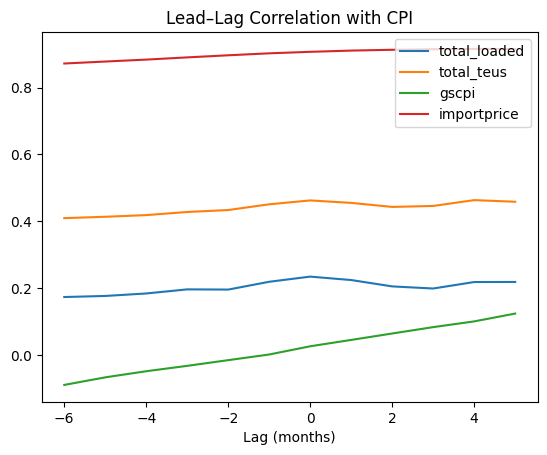

In [15]:
lags = np.arange(-6, 6)
for v in ['total_loaded','total_teus','gscpi','importprice']:
    crosscorr = [df['cpi_all'].corr(df[v].shift(l)) for l in lags]
    plt.plot(lags, crosscorr, label=v)
plt.legend(); plt.title("Lead–Lag Correlation with CPI"); plt.xlabel("Lag (months)"); plt.show()
